## NEP_Reduced_coordinate

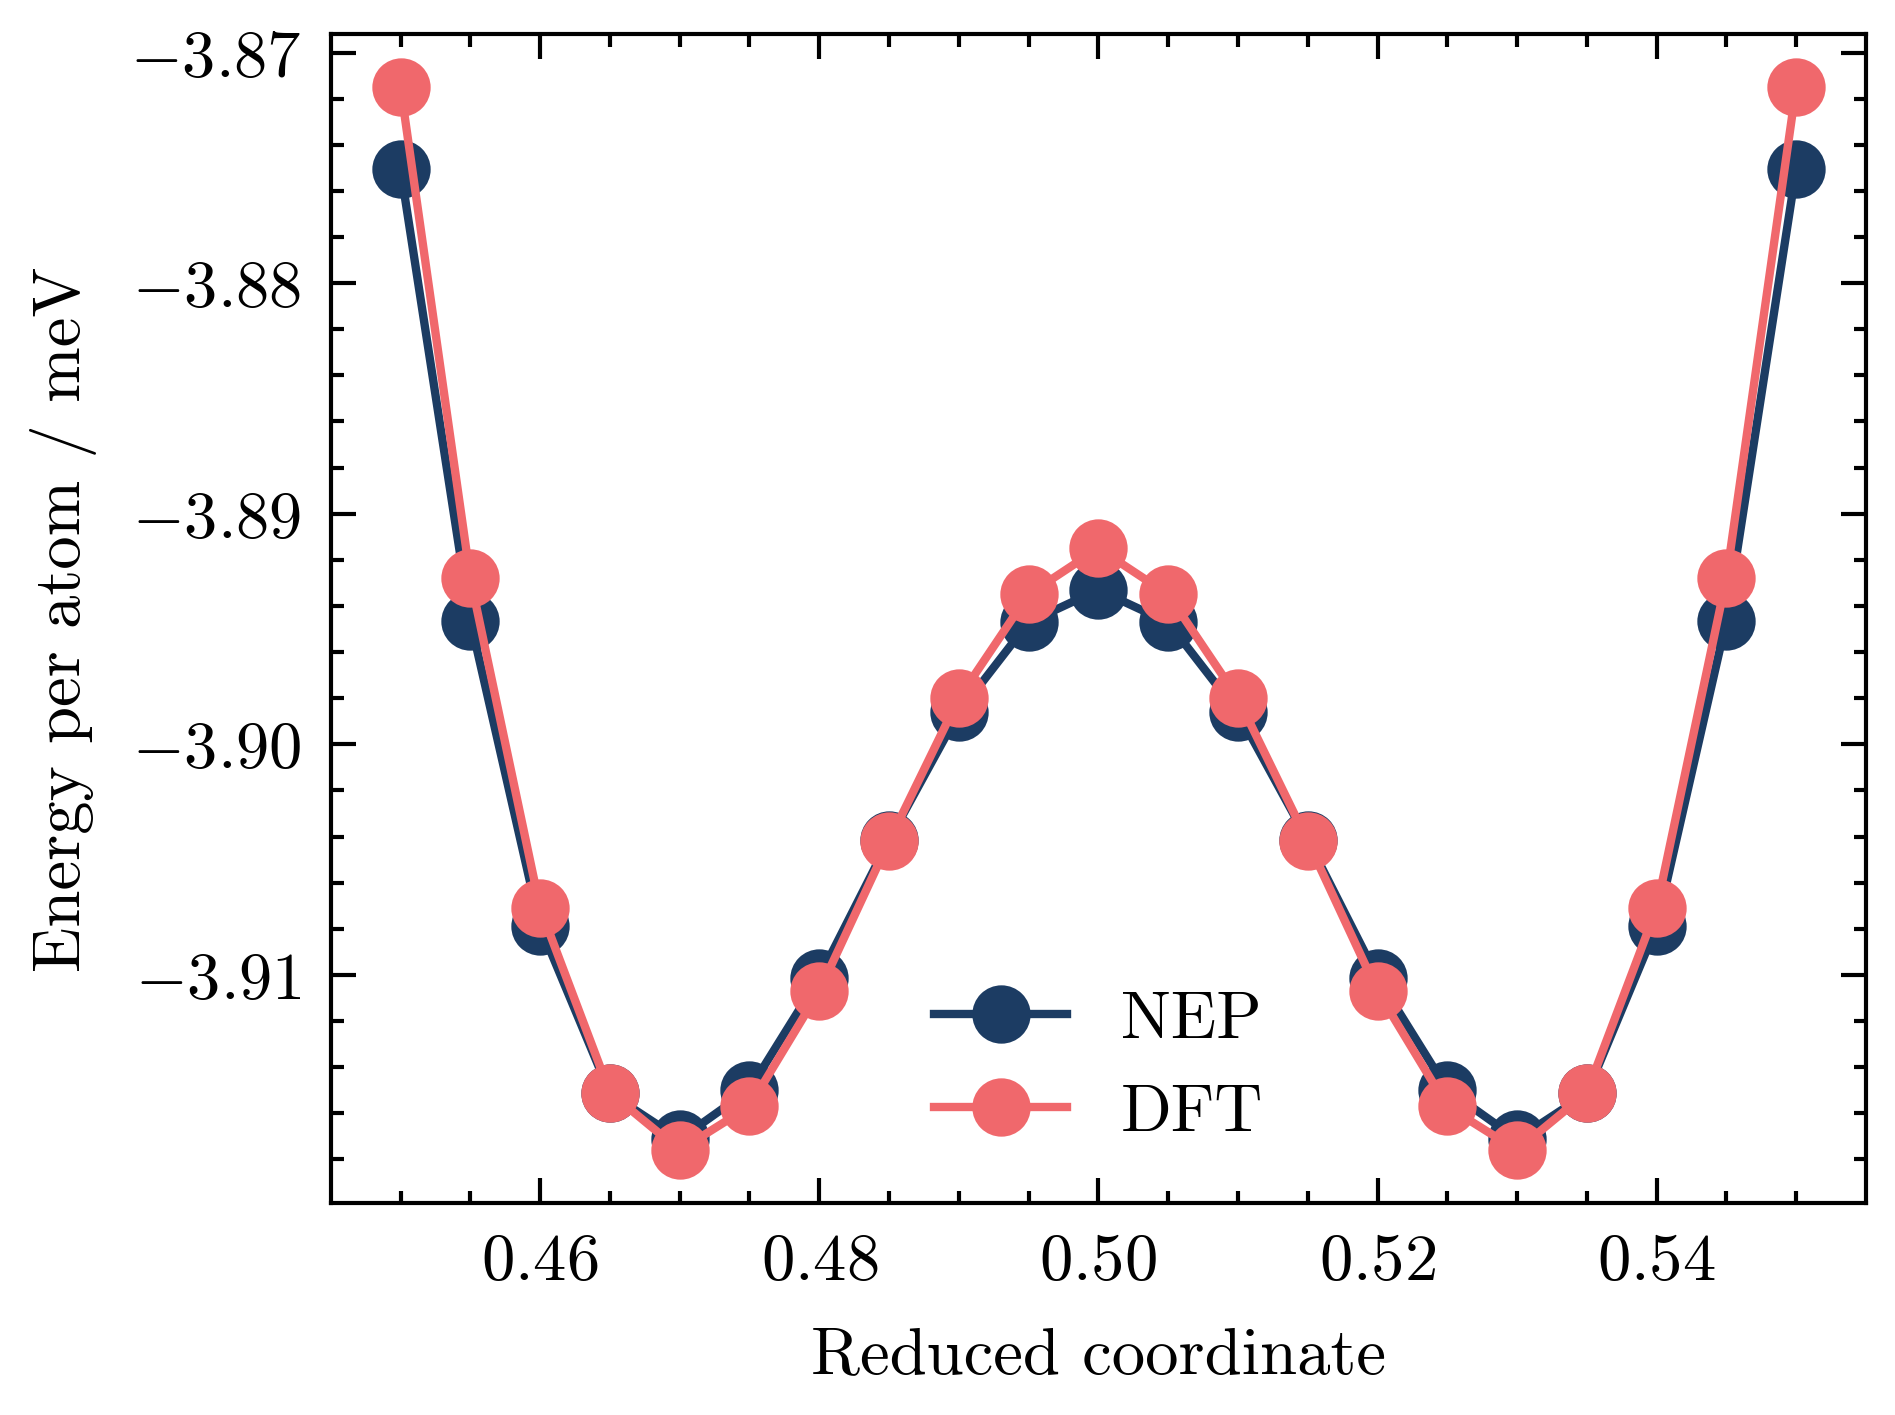

In [1]:
'''
文件名: coordbycalorine.py
运行方法: python coordbycalorine.py
功能描述: 计算结构在不同归一化坐标下的势能，绘制势能随归一化坐标变化的曲线，并将其保存为PNG图片。
'''

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scienceplots
import sys
from ase.calculators.mixing import SumCalculator
from ase.io import read, write
from ase.units import GPa
from calorine.calculators import CPUNEP
from calorine.tools import relax_structure
from dftd3.ase import DFTD3

# 设置绘图风格
plt.style.use(['science', 'ieee', 'no-latex', 'bright'])
colors = ["#1C3C63", "#F0686C"]

def nep_calculator(filename="../nep_GAP_GT.txt", use_dftd3=False):
    """
    配置NEP计算器，若需色散校正，则use_dftd3=True。
    """
    if os.path.exists(filename):
        if use_dftd3:
            return SumCalculator([CPUNEP(filename), DFTD3(method="pbe", damping="d3bj")])
        return CPUNEP(filename)
    print(f"文件 {filename} 不存在。")
    sys.exit(1)

# 读取初始结构
structure = read("./POSCAR")
data = []

# 遍历归一化坐标
for coord in np.arange(0.45, 0.55, 0.005):
    s = structure.copy()
    s.set_scaled_positions([(0., 0., 0.), (coord, coord, coord)])
    s.calc = nep_calculator()
    data.append(dict(coord=coord, energy=s.get_potential_energy() / len(structure)))
    # write(f'coord_{coord:.3f}.vasp', s)
df = pd.DataFrame(data)

### ----- DFT 数据 (可选) ----- ###
data = pd.DataFrame([[0.450, -3.8715],[0.455, -3.8928],[0.460, -3.9071],[0.465, -3.9151],
                     [0.470, -3.9176],[0.475, -3.9157],[0.480, -3.9107],[0.485, -3.9042],
                     [0.490, -3.8980],[0.495, -3.8935],[0.500, -3.8915],[0.505, -3.8935],
                     [0.510, -3.8980],[0.515, -3.9042],[0.520, -3.9107],[0.525, -3.9157],
                     [0.530, -3.9176],[0.535, -3.9151],[0.540, -3.9071],[0.545, -3.8928],
                     [0.550, -3.8715]], columns=["coord", "ene"])

coord = np.array(data["coord"])
dft = np.array(data["ene"])
### -------------------------- ###

# 绘制NEP的能量曲线
plt.figure()
plt.plot(df.coord, df.energy, 'o-', c=colors[0], label='NEP')
plt.plot(np.array(coord), np.array(dft), 'o-', c=colors[1], label="DFT")

plt.xlabel('Reduced coordinate')
plt.ylabel('Energy per atom / meV')
plt.legend(loc="best")
plt.tight_layout()

# 保存绘制的图像
plt.savefig('./coordinate.png', bbox_inches='tight')
